# Project Overview: Student Academic Success Prediction
**Objective:** To develop a high-performance machine learning model capable of predicting student academic outcomes by analyzing a comprehensive set of features, including socio-demographic backgrounds, academic performance, and macroeconomic indicators. 

## 1. Libraries & Workspace Setup

In [1]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s4e6')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/playground-series-s4e6


In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import joblib
import pickle

## 2. Data Acquisition & Initial Inspection

### 2.1. Loading Train and Test Datasets

In [3]:
train_df=pd.read_csv('/kaggle/input/competitions/playground-series-s4e6/train.csv')
test_df=pd.read_csv('/kaggle/input/competitions/playground-series-s4e6/test.csv')

In [4]:
train_df.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0,1,1,...,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,1,17,1,9238,1,1,125.0,1,19,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,3,1,1,3,9500,1,1,131.0,1,19,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,4,1,1,2,9500,1,1,132.0,1,19,...,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


In [5]:
test_df.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,76518,1,1,1,9500,1,1,141.0,1,3,...,0,0,8,0,0,0.000000,0,13.9,-0.3,0.79
1,76519,1,1,1,9238,1,1,128.0,1,1,...,0,0,6,6,6,13.500000,0,11.1,0.6,2.02
2,76520,1,1,1,9238,1,1,118.0,1,1,...,0,0,6,11,5,11.000000,0,15.5,2.8,-4.06
3,76521,1,44,1,9147,1,39,130.0,1,1,...,0,3,8,14,5,11.000000,0,8.9,1.4,3.51
4,76522,1,39,1,9670,1,1,110.0,1,1,...,0,0,6,9,4,10.666667,2,7.6,2.6,0.32


### 2.2. Checking Structural Metadata

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76518 entries, 0 to 76517
Data columns (total 38 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              76518 non-null  int64  
 1   Marital status                                  76518 non-null  int64  
 2   Application mode                                76518 non-null  int64  
 3   Application order                               76518 non-null  int64  
 4   Course                                          76518 non-null  int64  
 5   Daytime/evening attendance                      76518 non-null  int64  
 6   Previous qualification                          76518 non-null  int64  
 7   Previous qualification (grade)                  76518 non-null  float64
 8   Nacionality                                     76518 non-null  int64  
 9   Mother's qualification                 

In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51012 entries, 0 to 51011
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   id                                              51012 non-null  int64  
 1   Marital status                                  51012 non-null  int64  
 2   Application mode                                51012 non-null  int64  
 3   Application order                               51012 non-null  int64  
 4   Course                                          51012 non-null  int64  
 5   Daytime/evening attendance                      51012 non-null  int64  
 6   Previous qualification                          51012 non-null  int64  
 7   Previous qualification (grade)                  51012 non-null  float64
 8   Nacionality                                     51012 non-null  int64  
 9   Mother's qualification                 

In [8]:
train_df.isnull().sum()

id                                                0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship 

In [10]:
test_df.isnull().sum()

id                                                0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship 

## 3. Exploratory Data Analysis

In [11]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,76518.0,38258.500000,22088.988286,0.00,19129.250000,38258.500000,57387.750000,76517.000
Marital status,76518.0,1.111934,0.441669,1.00,1.000000,1.000000,1.000000,6.000
Application mode,76518.0,16.054419,16.682337,1.00,1.000000,17.000000,39.000000,53.000
Application order,76518.0,1.644410,1.229645,0.00,1.000000,1.000000,2.000000,9.000
Course,76518.0,9001.286377,1803.438531,33.00,9119.000000,9254.000000,9670.000000,9991.000
Daytime/evening attendance,76518.0,0.915314,0.278416,0.00,1.000000,1.000000,1.000000,1.000
Previous qualification,76518.0,3.658760,8.623774,1.00,1.000000,1.000000,1.000000,43.000
Previous qualification (grade),76518.0,132.378766,10.995328,95.00,125.000000,133.100000,140.000000,190.000
Nacionality,76518.0,1.226600,3.392183,1.00,1.000000,1.000000,1.000000,109.000
Mother's qualification,76518.0,19.837633,15.399456,1.00,1.000000,19.000000,37.000000,44.000


/tmp/ipykernel_57/3798107436.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_df, x='Target', palette='viridis', edgecolor='black')


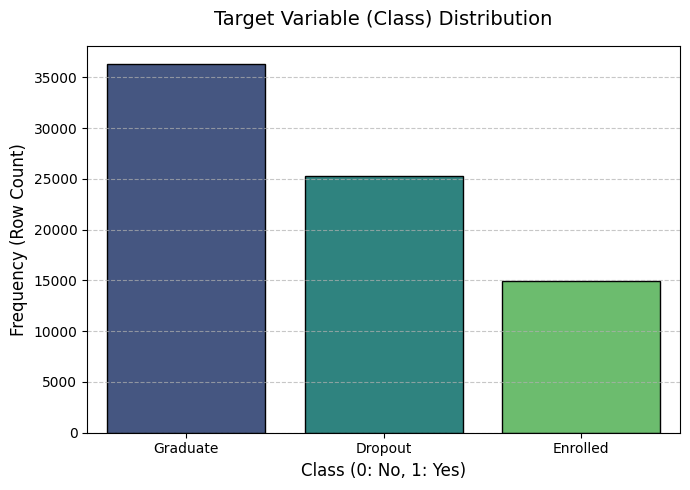

In [13]:
plt.figure(figsize=(7, 5))

sns.countplot(data=train_df, x='Target', palette='viridis', edgecolor='black')

plt.title('Target Variable (Class) Distribution', fontsize=14, pad=15)
plt.xlabel('Class (0: No, 1: Yes)', fontsize=12)
plt.ylabel('Frequency (Row Count)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7) 

plt.tight_layout()
plt.show()

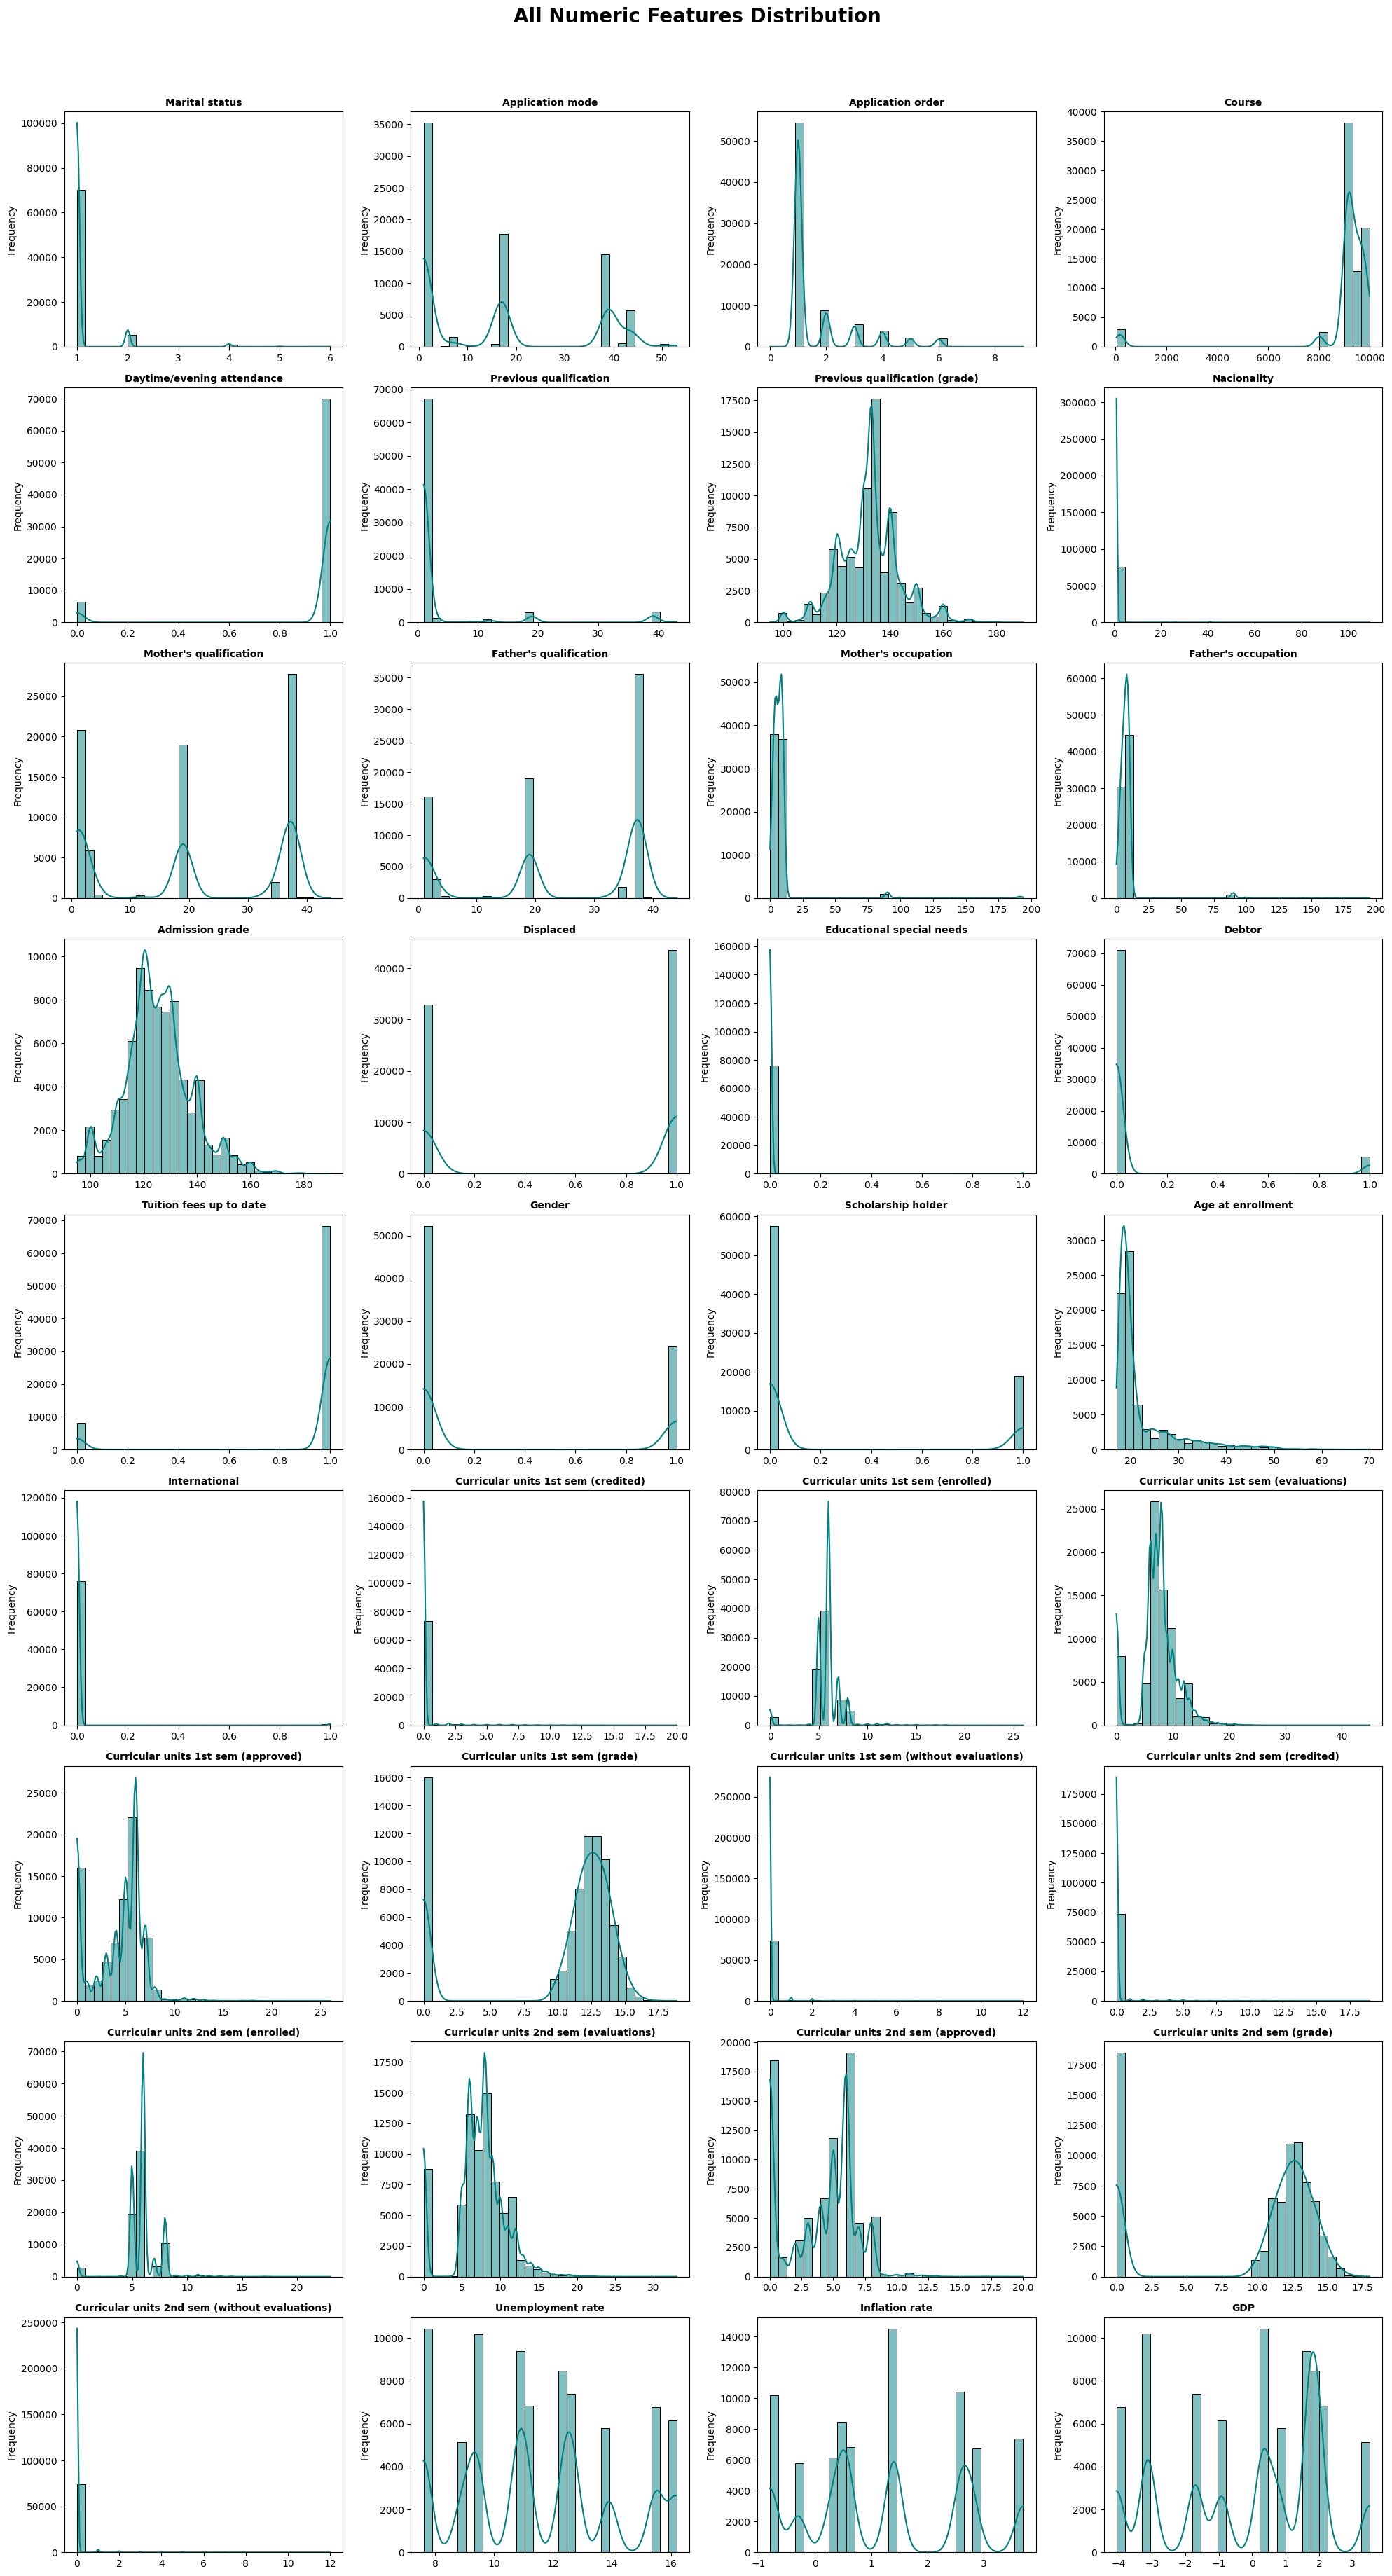

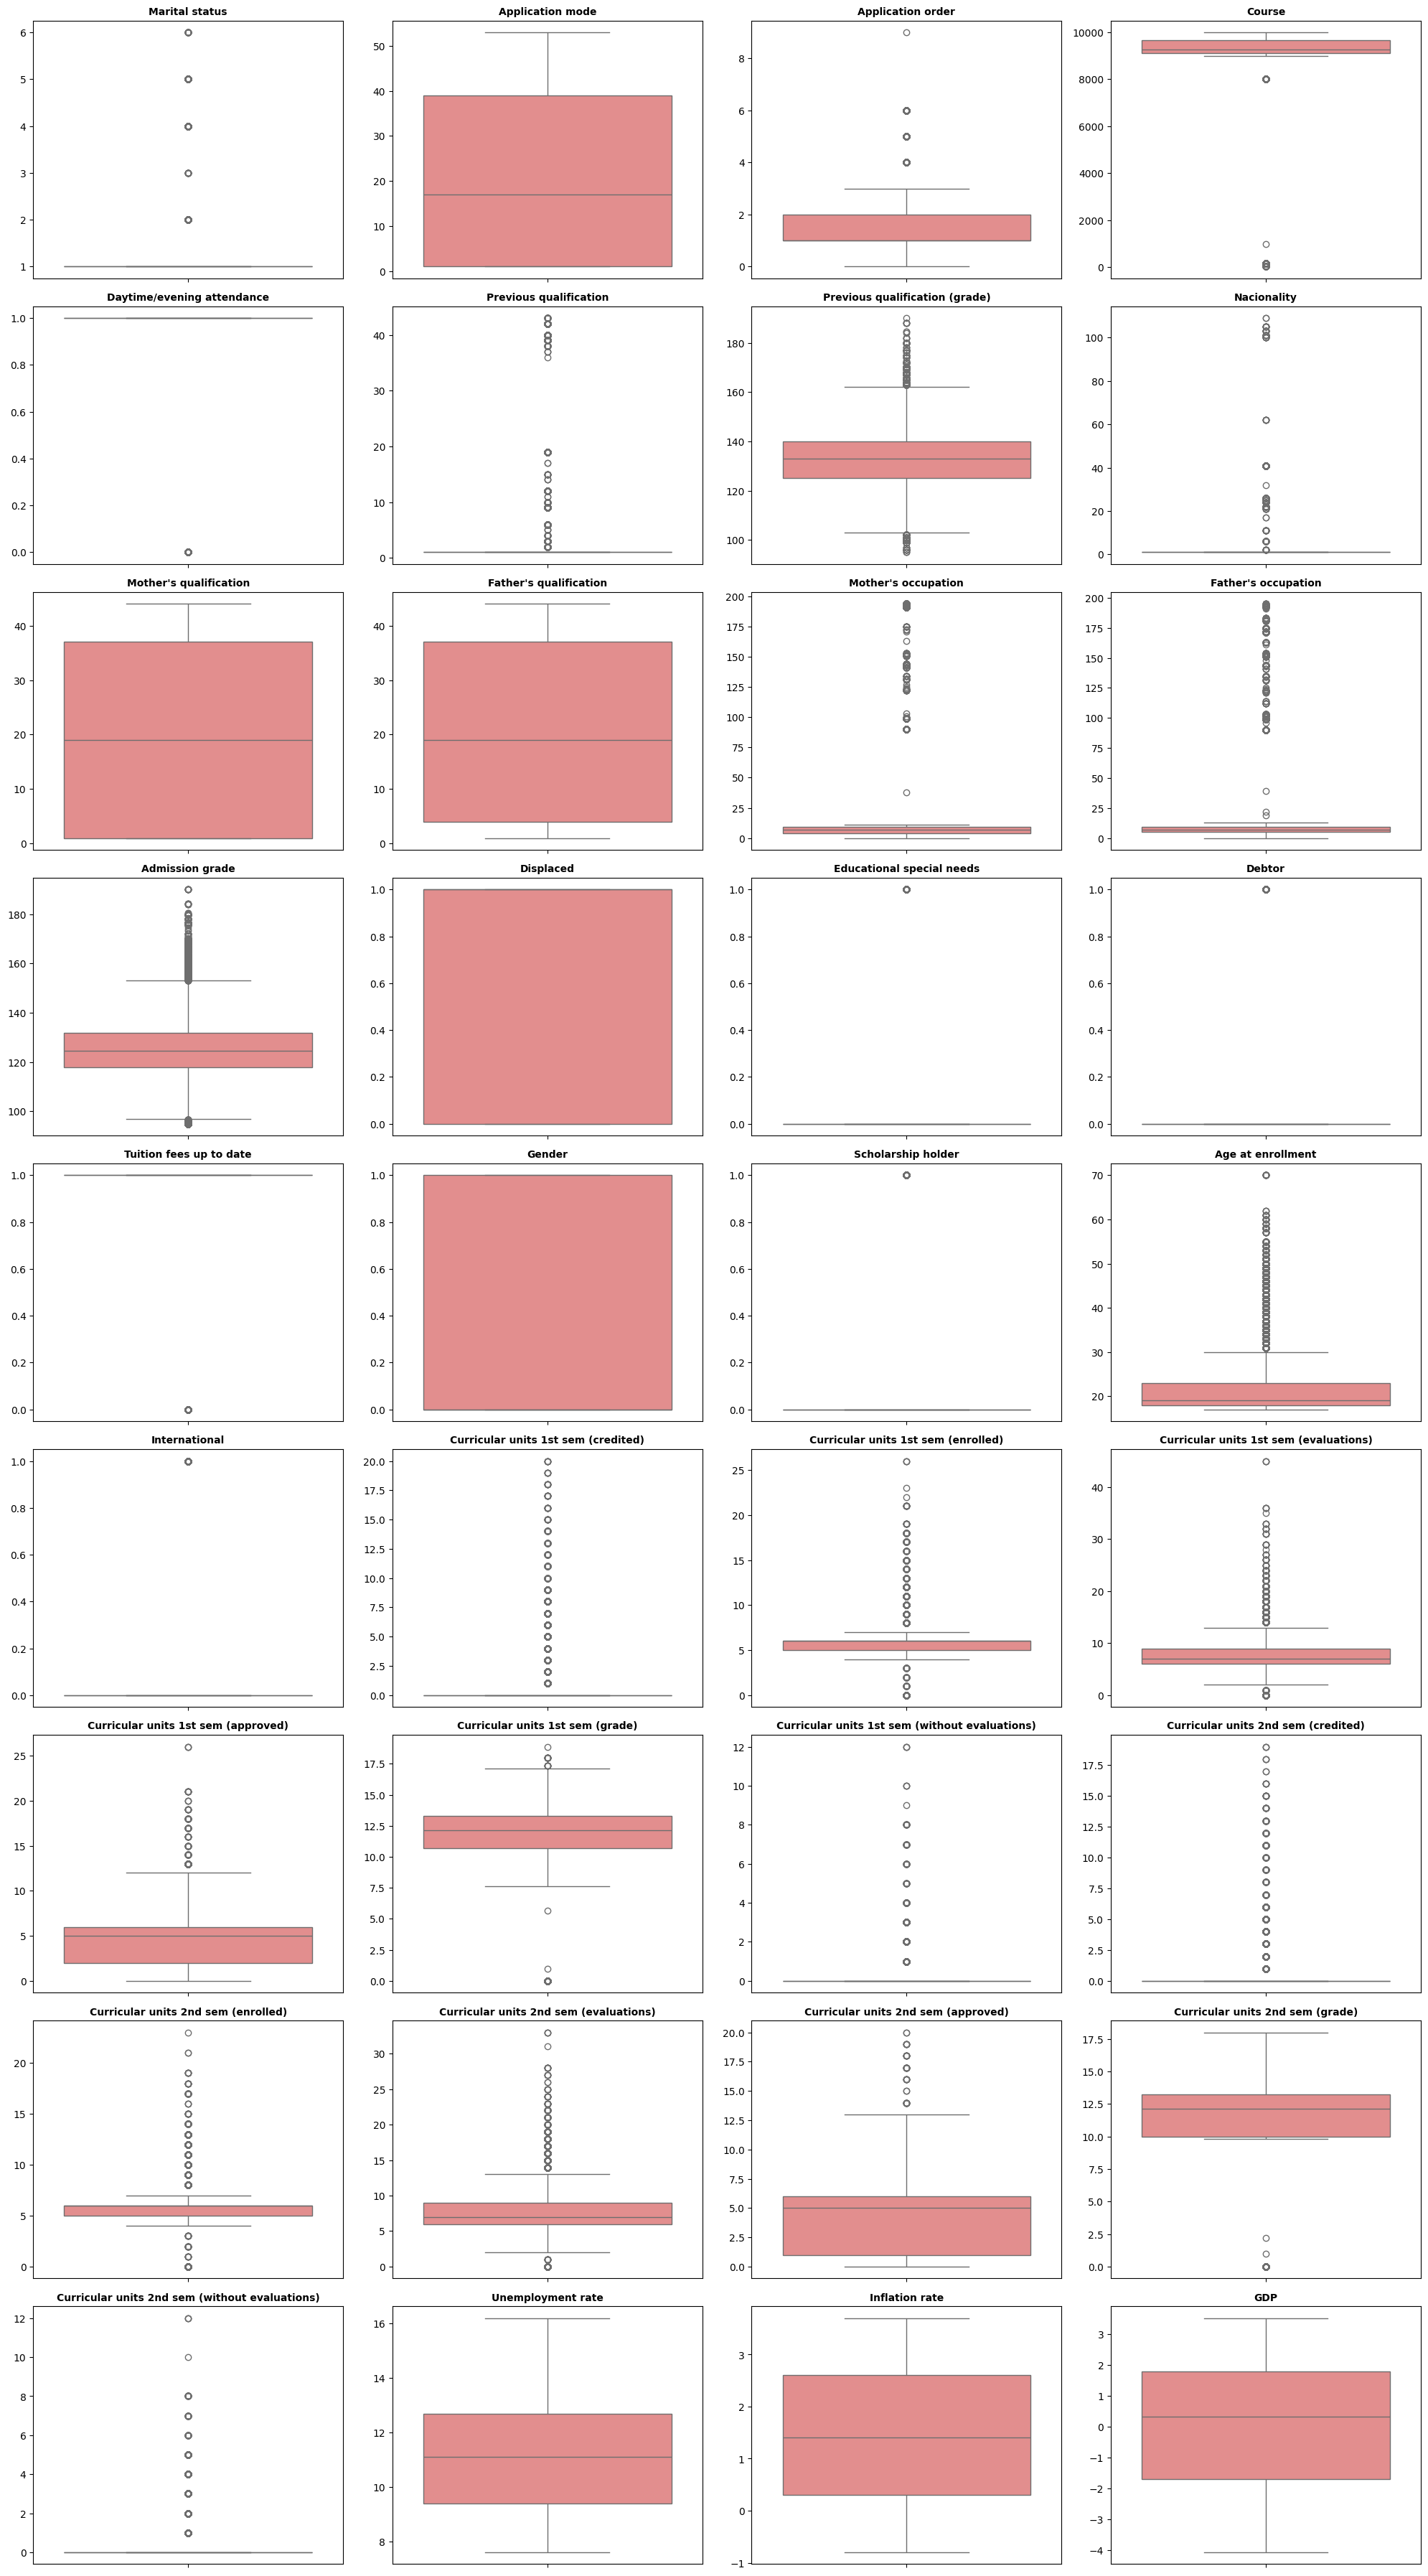

In [17]:
numeric_cols = train_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'id' in numeric_cols: numeric_cols.remove('id')
if 'Target' in numeric_cols: numeric_cols.remove('Target')

# Histogram
num_plots = len(numeric_cols)
cols_per_row = 4
rows = math.ceil(num_plots / cols_per_row)

fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(train_df[col].dropna(), kde=True, ax=axes[i], color='teal', bins=30)
    axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')

for i in range(num_plots, len(axes)):
    axes[i].axis('off')

plt.suptitle('All Numeric Features Distribution', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 3. Boxplot
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=train_df[col].dropna(), ax=axes[i], color='lightcoral')
    axes[i].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[i].set_ylabel('')

for i in range(num_plots, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 4. Feature Engineering (FE) & Data Preprocessing

In [18]:
binary_cols = ['Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'International']

In [21]:
train_df[binary_cols] = train_df[binary_cols].astype('category')
test_df[binary_cols] = test_df[binary_cols].astype('category')

In [23]:
le = LabelEncoder()

In [24]:
train_df['Target'] = le.fit_transform(train_df['Target'])

In [25]:
grade_cols = ['Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)']
for col in grade_cols:
    train_df[f'{col}_has_grade'] = (train_df[col] > 0).astype(int)
    test_df[f'{col}_has_grade'] = (test_df[col] > 0).astype(int)

In [29]:
train_df

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target,Curricular units 1st sem (grade)_has_grade,Curricular units 2nd sem (grade)_has_grade
0,0,1,1,1,9238,1,1,126.0,1,1,...,7,6,12.428571,0,11.1,0.6,2.02,2,1,1
1,1,1,17,1,9238,1,1,125.0,1,19,...,9,0,0.000000,0,11.1,0.6,2.02,0,1,0
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,0,0.000000,0,16.2,0.3,-0.92,0,0,0
3,3,1,1,3,9500,1,1,131.0,1,19,...,11,7,12.820000,0,11.1,0.6,2.02,1,1,1
4,4,1,1,2,9500,1,1,132.0,1,19,...,12,6,12.933333,0,7.6,2.6,0.32,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
76513,76513,1,17,1,9254,1,1,121.0,1,19,...,8,5,10.600000,0,13.9,-0.3,0.79,2,1,1
76514,76514,1,1,6,9254,1,1,125.0,1,1,...,9,6,13.875000,0,9.4,-0.8,-3.12,2,1,1
76515,76515,5,17,1,9085,1,1,138.0,1,37,...,8,5,11.400000,1,9.4,-0.8,-3.12,1,1,1
76516,76516,1,1,3,9070,1,1,136.0,1,38,...,0,0,0.000000,0,7.6,2.6,0.32,0,0,0


In [30]:
x = train_df.drop(columns=['Target', 'id'], errors='ignore')
y = train_df['Target']

In [31]:
x.shape

(76518, 38)

In [32]:
y.shape

(76518,)

In [33]:
x_test_final = test_df.drop(columns=['id'], errors='ignore')

In [35]:
x_test_final.shape

(51012, 38)

## 5. Model Training, Optimization & Deployment Strategy

In [37]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import BernoulliNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def algo_test(x, y):
    b = BernoulliNB()
    l = LogisticRegression(max_iter=2000, class_weight='balanced', n_jobs=-1, random_state=42)
    d = DecisionTreeClassifier(max_depth=15, class_weight='balanced', random_state=42)
    r = RandomForestClassifier(n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=42)
    gb = GradientBoostingClassifier(n_estimators=50, random_state=42)
    kn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
    ab = AdaBoostClassifier(algorithm='SAMME', random_state=42)
    svc = LinearSVC(class_weight='balanced', max_iter=2000, random_state=42, dual="auto")
    xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
    lgb = LGBMClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, class_weight='balanced', n_jobs=-1, random_state=42, verbose=-1)

    models = [b, l, d, r, gb, kn, ab, svc, xgb, lgb]
    model_names = [
        "BernoulliNB", "LogisticRegression", "DecisionTreeClassifier", 
        "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
        "AdaBoostClassifier", "LinearSVC", "XGBClassifier", "LGBMClassifier"
    ]

    x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
        x, y, test_size=0.20, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train_split), columns=x_train_split.columns)
    x_val_scaled = pd.DataFrame(scaler.transform(x_val_split), columns=x_val_split.columns)
    
    accuracy, precision, recall, f1 = [], [], [], []
    successful_models, successful_names = [], []

    for model, name in zip(models, model_names):
        print(f"--> Training {name}...")
        try:
            model.fit(x_train_scaled, y_train_split)
            prediction = model.predict(x_val_scaled)
            
            accuracy.append(accuracy_score(y_val_split, prediction))
            precision.append(precision_score(y_val_split, prediction, average='weighted', zero_division=0))
            recall.append(recall_score(y_val_split, prediction, average='weighted', zero_division=0))
            f1.append(f1_score(y_val_split, prediction, average='weighted', zero_division=0))
            
            successful_models.append(model)
            successful_names.append(name)
        except Exception as e:
            print(f" [!] Error in {name}: {e}")

    metrics = pd.DataFrame({"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1}, index=successful_names)
    metrics["Model_Object"] = successful_models
    metrics.sort_values("F1", ascending=False, inplace=True)
    
    return metrics

In [39]:
results = algo_test(x, y)

--> Training BernoulliNB...
--> Training LogisticRegression...
--> Training DecisionTreeClassifier...
--> Training RandomForestClassifier...
--> Training GradientBoostingClassifier...
--> Training KNeighborsClassifier...
--> Training AdaBoostClassifier...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


--> Training LinearSVC...
--> Training XGBClassifier...
--> Training LGBMClassifier...


In [41]:
results

,Accuracy,Precision,Recall,F1,Model_Object
XGBClassifier,0.826124,0.824964,0.826124,0.823526,"XGBClassifier(base_score=None, booster=None, c..."
GradientBoostingClassifier,0.823641,0.821937,0.823641,0.821123,([DecisionTreeRegressor(criterion='friedman_ms...
RandomForestClassifier,0.824098,0.821239,0.824098,0.820679,"(DecisionTreeClassifier(max_features='sqrt', r..."
LGBMClassifier,0.812533,0.835767,0.812533,0.819716,"LGBMClassifier(class_weight='balanced', learni..."
LinearSVC,0.806979,0.816454,0.806979,0.808982,"LinearSVC(class_weight='balanced', max_iter=20..."
LogisticRegression,0.800967,0.825251,0.800967,0.808680,"LogisticRegression(class_weight='balanced', ma..."
AdaBoostClassifier,0.811553,0.807340,0.811553,0.807318,"(DecisionTreeClassifier(max_depth=1, random_st..."
DecisionTreeClassifier,0.778097,0.802407,0.778097,0.786459,DecisionTreeClassifier(class_weight='balanced'...
BernoulliNB,0.784631,0.796296,0.784631,0.786165,BernoulliNB()
KNeighborsClassifier,0.776986,0.769766,0.776986,0.771877,KNeighborsClassifier(n_jobs=-1)


In [42]:
x_raw_train, x_raw_val, y_raw_train, y_raw_val = train_test_split(x, y, test_size=0.20, random_state=42, stratify=y)

In [43]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_raw_train)
x_val_scaled = scaler.transform(x_raw_val)

In [44]:
xgb = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)

In [45]:
xgb.fit(x_train_scaled, y_raw_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [53]:
y_pred = xgb.predict(x_val_scaled)

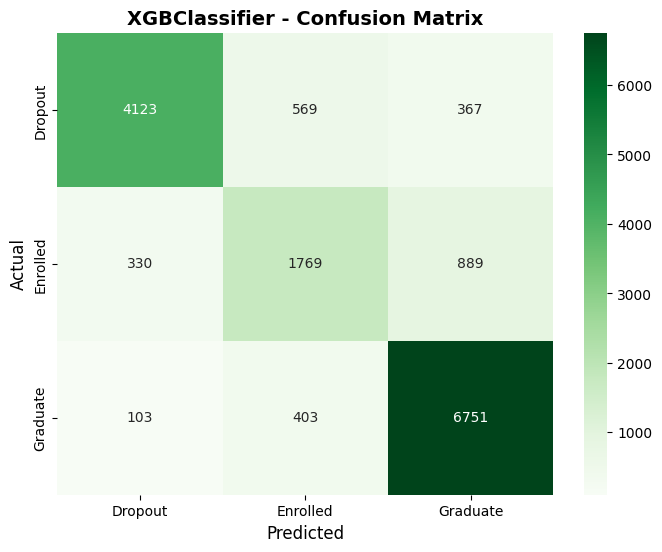

In [55]:
cm = confusion_matrix(y_raw_val, y_pred)

# Görselleştirme
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Dropout', 'Enrolled', 'Graduate'], 
            yticklabels=['Dropout', 'Enrolled', 'Graduate'])

plt.title('XGBClassifier - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()

In [56]:
final_scaler = StandardScaler()
x_final_train_scaled = final_scaler.fit_transform(x)
x_final_test_scaled = final_scaler.transform(x_test_final)

In [57]:
final_model = XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)

In [59]:
final_model.fit(x_final_train_scaled, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [60]:
final_predictions = final_model.predict(x_final_test_scaled)

In [61]:
predicted_labels = le.inverse_transform(final_predictions)

In [63]:
submission = pd.DataFrame({
    'id': test_df['id'], 
    'Target': predicted_labels
})

submission.to_csv('submission.csv', index=False)

In [65]:
joblib.dump(final_model, 'academic_final_model.joblib')
joblib.dump(final_scaler, 'academic_final_scaler.joblib')

['academic_final_scaler.joblib']

In [66]:
with open('academic_final_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('academic_final_scaler.pkl', 'wb') as f:
    pickle.dump(final_scaler, f)